# Demand Forecasting with Censored Likelihood with `numpyro_forecast`

This notebook ports the blog post [**Demand Forecasting with Censored Likelihood**](https://juanitorduz.github.io/demand/) to the [`numpyro_forecast`](https://github.com/juanitorduz/numpyro_forecast) package. The subject is a fact of retail life: recorded sales understate demand in two distinct ways. When the product is out of stock, a day of genuine demand is recorded as zero sales. And when demand exceeds what the shelf (or the supply) can carry, the register stops counting at the capacity cap, so the recorded number is a *lower bound* on what customers actually wanted. A model trained naively on such a series learns to forecast *sales*, but replenishment and capacity planning need a forecast of *demand*: order against sales and you bake yesterday's stockouts into tomorrow's assortment, systematically under-serving your best days.

We simulate a demand series from an AR(2) process with weekly seasonality, corrupt it into observed sales through random stockouts and a hard capacity cap, and then fit an AR(2) model with Fourier seasonality **whose likelihood knows about the censoring**: below the cap an observation contributes the usual $\text{Normal}$ density, and at the cap it contributes the *survival mass* $P(\text{demand} \geq \text{cap})$, the probability that latent demand was at least as large as the recorded bound. Days with the product off the shelf are masked out of the likelihood entirely. Because the data are simulated, the true demand is known and the claim "the censored likelihood recovers demand" can be checked against ground truth rather than asserted.

Three practical notes on the port:

- The blog post implements the censoring by hand, with a Bernoulli site on the complementary CDF inside a `scan` over time plus `condition` and `mask` handlers. Since the blog post was written, NumPyro (from version `0.20.0`) ships this construction as [`RightCensoredDistribution`](https://num.pyro.ai/en/stable/distributions.html#censored-distributions), including a numerical-stability clip on the CDF, so the whole likelihood becomes a single vectorized `"obs"` site. The in-sample recursion follows the same two-scan pattern as the [ARMA example](https://juanitorduz.github.io/numpyro_forecast/examples/arma.html): a deterministic filter over the observed history for training, and a generative scan that feeds sampled innovations back into the carry for the forecast.
- The blog post benchmarks against an ARIMA model from statsmodels. Here the baseline is sharper: **the identical model with the censoring indicator switched off**. With the indicator at zero everywhere, `RightCensoredDistribution` reduces exactly to a plain $\text{Normal}$ likelihood, so the baseline differs from the censored model by one covariate column and nothing else, isolating exactly what the censored likelihood buys.
- This example completes a trio of availability mechanisms in this documentation. The [availability TSB example](https://juanitorduz.github.io/numpyro_forecast/examples/availability_tsb.html) freezes its recursion updates when the product is off the shelf, and the [fresh retail stockout example](https://juanitorduz.github.io/numpyro_forecast/examples/fresh_retail_stockout.html) scales the mean by a saturating availability factor; its next-steps list asks for precisely the model built here. The closing section compares the three mechanisms side by side.

## Prepare notebook

In [1]:
from dataclasses import dataclass
from functools import partial
from typing import NamedTuple, cast

import arviz as az
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
import pandas as pd
import xarray as xr
from jax import random
from jaxtyping import Float
from matplotlib.artist import Artist
from matplotlib.axes import Axes

from numpyro_forecast import (
    eval_coverage,
    eval_crps,
    eval_mae,
    eval_rmse,
    evaluate_forecast,
    forecasting_model,
    predictions_to_datatree,
    to_datatree,
)
from numpyro_forecast.features import fourier_features
from numpyro_forecast.functional import Horizon, fit_mcmc
from numpyro_forecast.typing import Array

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

numpyro.set_host_device_count(n=4)

rng_key = random.PRNGKey(seed=42)


%load_ext autoreload
%autoreload 2
%load_ext jaxtyping
%jaxtyping.typechecker beartype.beartype
%config InlineBackend.figure_format = "retina"

## Generate data

We reproduce the blog post's data generating process (swapping its pydantic parameter class for a frozen dataclass and its Python loop for a [`jax.lax.scan`](https://docs.jax.dev/en/latest/_autosummary/jax.lax.scan.html), the same idiom the model uses). Latent demand follows an AR(2) recursion with a weekly sinusoid, clipped at zero:

$$d_t = \max\left(0, \; \phi_1 \, d_{t-1} + \phi_2 \, d_{t-2} + \gamma \sin\left(\frac{2\pi t}{7}\right) + c + \varepsilon^d_t\right), \qquad \varepsilon^d_t \sim \text{Normal}(0, \sigma_d).$$

Sales are demand minus a friction term and noise, never exceeding demand and never negative:

$$s_t = \max\left(0, \; \min\left(d_t + \varepsilon^s_t - \delta, \; d_t\right)\right), \qquad \varepsilon^s_t \sim \text{Normal}(0, \sigma_s).$$

Observed sales gate the sales through an availability coin flip and cap them at the shelf capacity:

$$a_t \sim \text{Bernoulli}(0.8), \qquad y_t = \min\left(a_t \, s_t, \; y_{\max}\right), \qquad y_{\max} = 2.2.$$

It pays to keep the four quantities straight, because the whole example is about the gaps between them:

- **Latent demand** $d_t$ is what customers want on day $t$. It is never observed directly, and it is the number planning cares about.
- **Sales** $s_t$ are what would sell with the product fully available: demand minus real-world friction (a customer walks away, a basket is abandoned), which is why $s_t \leq d_t$ always.
- **Observed sales** $y_t$ are the only column a transaction database records: sales zeroed out on stockout days and truncated at the capacity cap.
- **Availability** $a_t$ says whether the product was on the shelf at all. Retail systems typically know this (or can reconstruct it from inventory snapshots), which is what makes the model below feasible in practice.

From the observed series we also derive the **censoring indicator** $c_t = \mathbb{1}\{y_t = y_{\max}\}$: on those days the register hit the cap, so the recorded value is a lower bound on sales rather than a measurement of them.

In [2]:
@dataclass(frozen=True)
class DemandParams:
    """Parameters of the demand and sales data generating process.

    Attributes
    ----------
    n_periods
        Number of days to simulate.
    phi_1, phi_2
        AR(2) coefficients of the latent demand recursion.
    seasonal_amplitude
        Amplitude of the weekly sinusoid in the demand recursion.
    seasonal_period
        Seasonal period in days.
    intercept
        Constant term of the demand recursion.
    demand_init
        Initial demand level seeding both lags of the recursion.
    demand_noise, sales_noise
        Standard deviations of the demand and sales noise terms.
    demand_sales_delta
        Friction subtracted from demand when generating sales.
    availability_rate
        Probability that the product is on the shelf on a given day.
    max_capacity
        Hard cap on recorded daily sales.
    """

    n_periods: int = 180
    phi_1: float = 0.6
    phi_2: float = 0.3
    seasonal_amplitude: float = 0.6
    seasonal_period: int = 7
    intercept: float = 0.2
    demand_init: float = 2.0
    demand_noise: float = 0.3
    sales_noise: float = 0.5
    demand_sales_delta: float = 0.25
    availability_rate: float = 0.8
    max_capacity: float = 2.2


class DemandData(NamedTuple):
    """Simulated series of the demand and sales process.

    Attributes
    ----------
    demand
        Latent demand series.
    sales
        Sales under full availability.
    sales_obs
        Observed sales: availability-gated and capacity-capped.
    is_available
        Availability indicator (1 if the product was on the shelf).
    """

    demand: Float[Array, " t"]
    sales: Float[Array, " t"]
    sales_obs: Float[Array, " t"]
    is_available: Float[Array, " t"]


def generate_demand_sales(rng_key: Array, params: DemandParams) -> DemandData:
    """Simulate latent demand, sales, and observed sales.

    Parameters
    ----------
    rng_key
        PRNG key for the noise terms and the availability draws.
    params
        Parameters of the data generating process.

    Returns
    -------
    DemandData
        The four simulated series, each of length ``params.n_periods``.
    """
    key_demand, key_sales, key_avail = random.split(rng_key, 3)
    noise_demand = params.demand_noise * random.normal(key_demand, (params.n_periods,))
    noise_sales = params.sales_noise * random.normal(key_sales, (params.n_periods,))
    is_available = random.bernoulli(
        key_avail, params.availability_rate, (params.n_periods,)
    ).astype(jnp.float32)
    t_grid = jnp.arange(params.n_periods, dtype=jnp.float32)

    def dgp_step(carry, xs):
        demand_prev_1, demand_prev_2 = carry
        t, eps_demand, eps_sales = xs
        seasonal = params.seasonal_amplitude * jnp.sin(2 * jnp.pi * t / params.seasonal_period)
        demand_t = jnp.clip(
            params.phi_1 * demand_prev_1
            + params.phi_2 * demand_prev_2
            + seasonal
            + params.intercept
            + eps_demand,
            min=0.0,
        )
        sales_t = jnp.clip(
            jnp.minimum(demand_t + eps_sales - params.demand_sales_delta, demand_t),
            min=0.0,
        )
        return (demand_t, demand_prev_1), (demand_t, sales_t)

    init = (jnp.asarray(params.demand_init), jnp.asarray(params.demand_init))
    _, (demand, sales) = jax.lax.scan(dgp_step, init, (t_grid, noise_demand, noise_sales))
    sales_obs = jnp.minimum(is_available * sales, params.max_capacity)
    return DemandData(demand=demand, sales=sales, sales_obs=sales_obs, is_available=is_available)


params = DemandParams()
rng_key, rng_subkey = random.split(rng_key)
demand, sales, sales_obs, is_available = generate_demand_sales(rng_subkey, params)

censored = (sales_obs == params.max_capacity).astype(jnp.float32)
time = np.arange(params.n_periods)

n_stockout = int((1 - is_available).sum())
n_censored = int(censored.sum())
print(f"periods: {params.n_periods}")
print(f"stockout days: {n_stockout} ({n_stockout / params.n_periods:.0%})")
print(f"capacity-censored days: {n_censored} ({n_censored / params.n_periods:.0%})")

periods: 180
stockout days: 49 (27%)
capacity-censored days: 36 (20%)


The plot makes the two corruption mechanisms visible at once. Wherever the latent demand (blue) rides above the dashed capacity cap, the observed sales (black) flatline at $y_{\max}$ and the censored days light up in orange; on the shaded stockout days the observed series drops to zero regardless of how much demand there was. The sales series (green) hugs demand from below everywhere else.

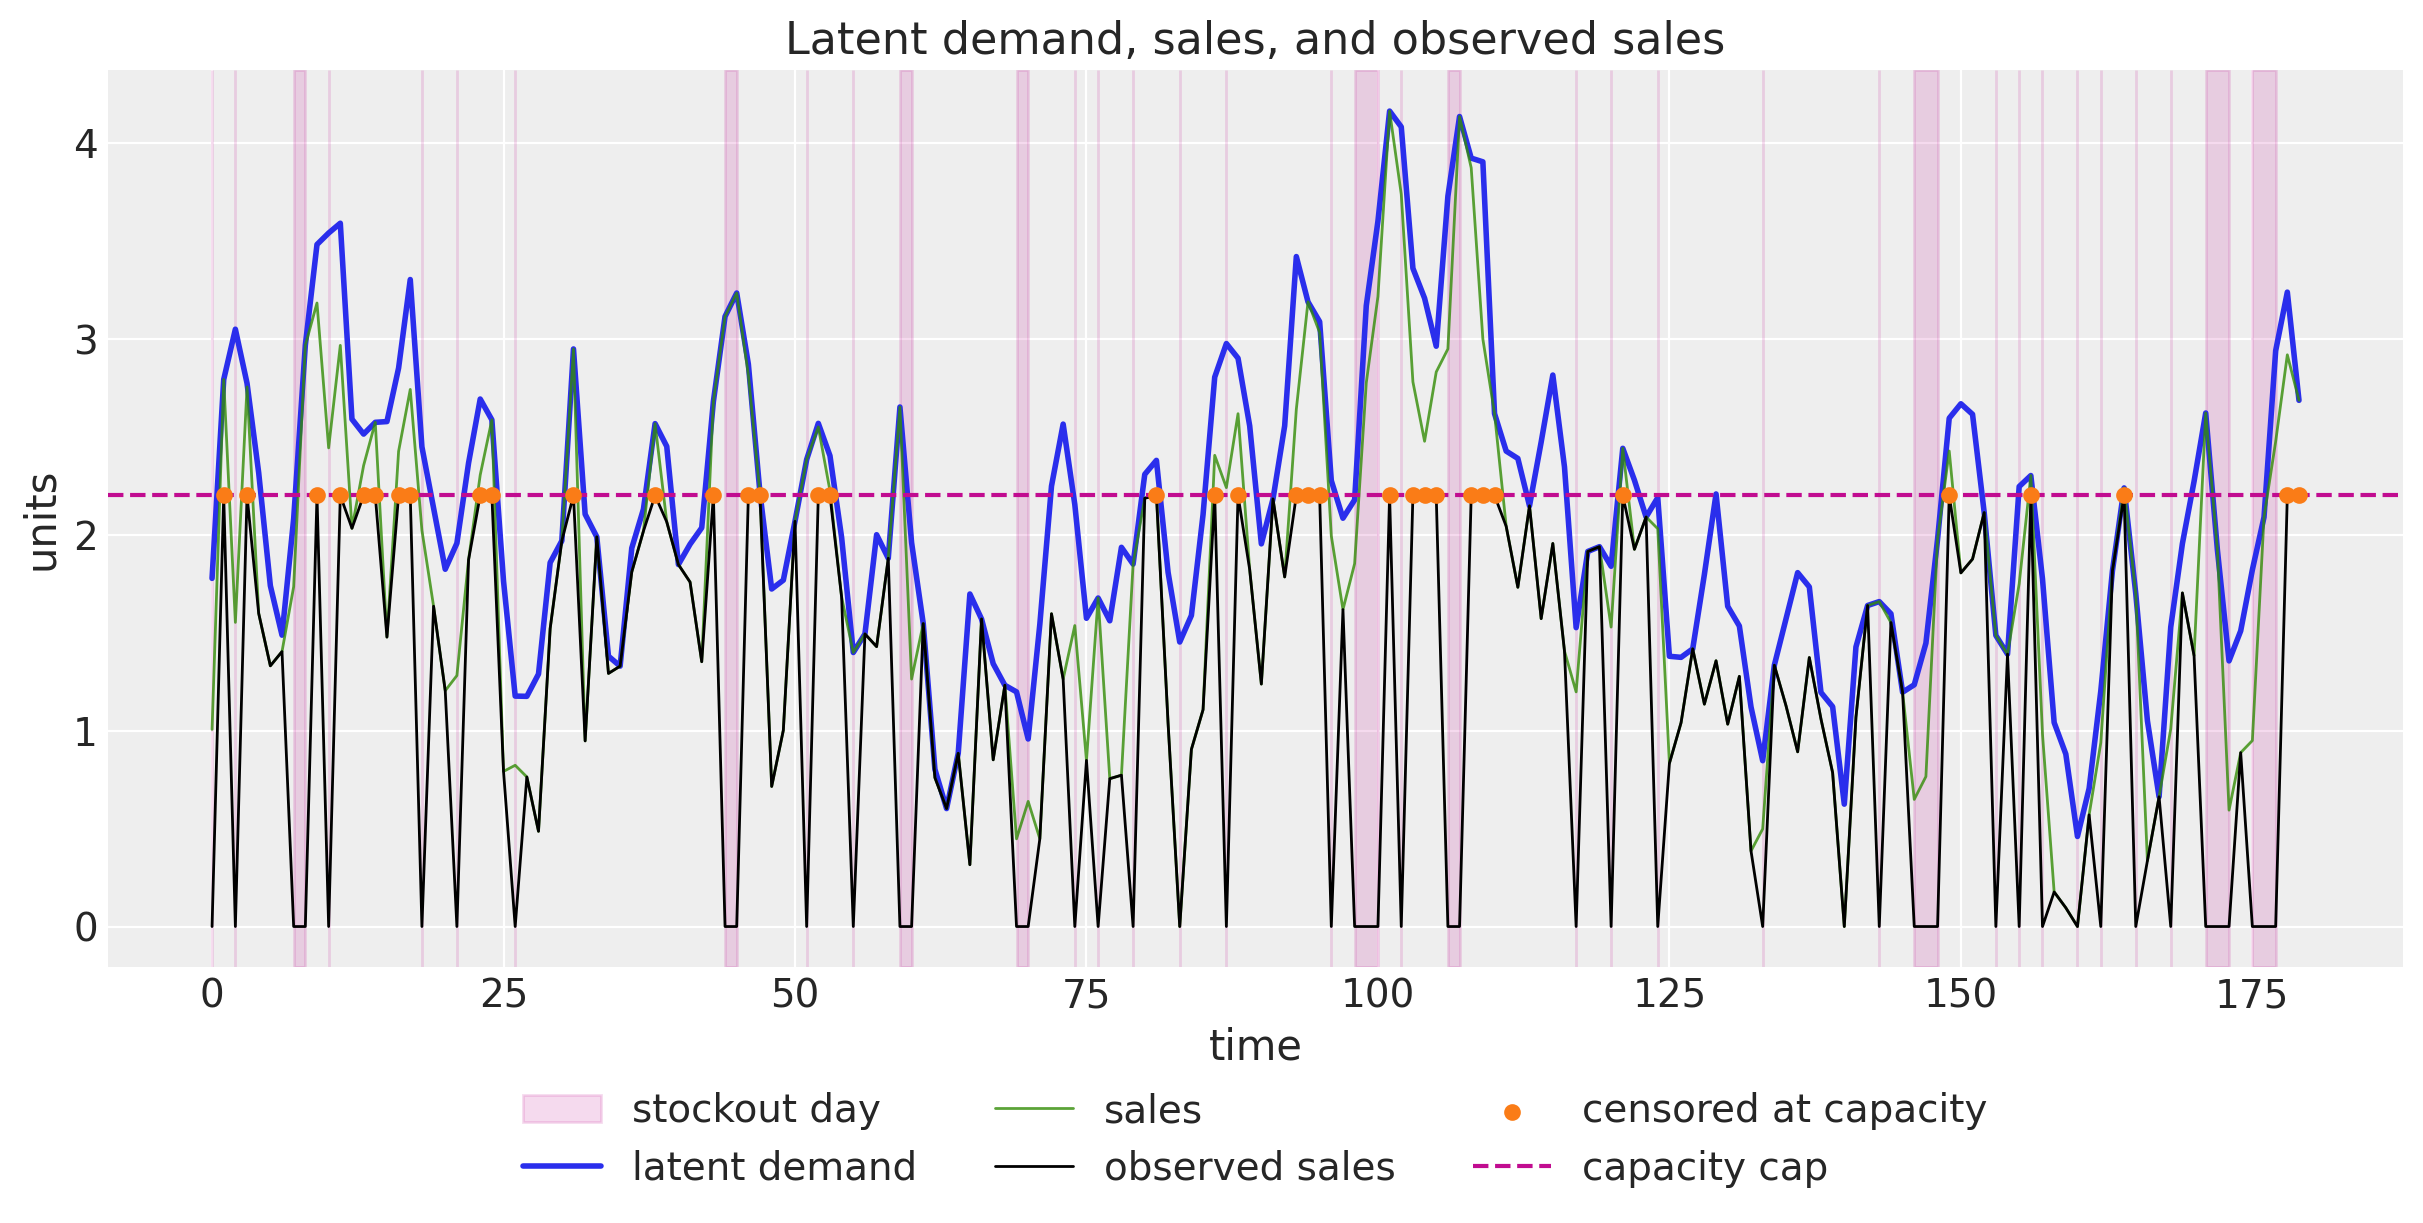

In [3]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.fill_between(
    time,
    0,
    1,
    where=(np.asarray(is_available) == 0).tolist(),
    transform=ax.get_xaxis_transform(),
    color="C3",
    alpha=0.15,
    step="mid",
    label="stockout day",
)
ax.plot(time, np.asarray(demand), color="C0", lw=2, label="latent demand")
ax.plot(time, np.asarray(sales), color="C2", lw=1, alpha=0.8, label="sales")
ax.plot(time, np.asarray(sales_obs), color="black", lw=1, label="observed sales")
ax.scatter(
    time[np.asarray(censored) == 1],
    np.asarray(sales_obs)[np.asarray(censored) == 1],
    color="C1",
    s=25,
    zorder=5,
    label="censored at capacity",
)
ax.axhline(params.max_capacity, color="C3", ls="--", lw=1.5, label="capacity cap")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=3)
ax.set(title="Latent demand, sales, and observed sales", xlabel="time", ylabel="units");

## Train-test split and covariates

We hold out the last $30$ days as the test window (a simple fixed-origin split, as in the blog post). Throughout the package, time lives at axis `-2` and the observation dimension at axis `-1`, so the training data has shape `(150, 1)`.

The covariates carry everything the model needs over the **full** duration, in a `(180, 7)` tensor. The package infers the forecast horizon from the shapes: covariates longer than the data by $30$ rows means a $30$-step forecast.

- Column `0` is the observed sales history the AR recursion filters. Only the first `t_obs` rows are ever read, so the future rows are zeroed out and no information leaks.
- Column `1` is the availability mask and column `2` the censoring indicator. Their trailing $30$ rows encode the **forecast scenario**: availability pinned to one and censoring to zero, meaning the forecast describes *uncensored demand*, the number a planner should order against. This is the same covariates-as-scenario device the availability TSB and fresh retail examples use.
- Columns `3:7` are weekly Fourier features (two harmonics, sines then cosines) from the package's [`fourier_features`](https://juanitorduz.github.io/numpyro_forecast/reference/features.fourier_features.html) helper, the only columns the model reads over the horizon.

In [4]:
forecast_horizon = 30
n_train = params.n_periods - forecast_horizon

train_data = sales_obs[:n_train][:, None]
demand_test = demand[n_train:][:, None]
sales_obs_test = sales_obs[n_train:][:, None]
t_test = time[n_train:]

n_order = 2
fourier = fourier_features(params.n_periods, float(params.seasonal_period), n_order)

in_train = jnp.arange(params.n_periods) < n_train
covariates = jnp.concatenate(
    [
        jnp.where(in_train, sales_obs, 0.0)[:, None],  # history; future rows never read
        jnp.where(in_train, is_available, 1.0)[:, None],  # scenario: fully available
        jnp.where(in_train, censored, 0.0)[:, None],  # scenario: uncensored
        fourier,
    ],
    axis=-1,
)
covariates_train = covariates[:n_train]
print(f"train data shape: {train_data.shape}, full covariates shape: {covariates.shape}")

train data shape: (150, 1), full covariates shape: (180, 7)


## Model specification

The mean recursion is the blog post's AR(2) with Fourier seasonality, run on the *observed sales* series:

$$\hat{y}_t = \mu + \phi_1 \, y_{t-1} + \phi_2 \, y_{t-2} + s_t, \qquad s_t = \mathbf{f}_t^\top \boldsymbol{\beta},$$

with priors

\begin{align*}
\mu & \sim \text{Normal}(1, 1), \\
\phi_1, \phi_2 & \sim \text{Normal}(0, 1), \\
\boldsymbol{\beta} & \sim \text{Normal}(0, 1), \\
\sigma & \sim \text{HalfNormal}(1).
\end{align*}

The likelihood is where the censoring lives. An uncensored day contributes the usual density; a censored day only tells us that latent sales were *at least* the cap, so it contributes the survival mass above the recorded value:

$$p(y_t \mid \hat{y}_t, \sigma) = \text{Normal}(y_t \mid \hat{y}_t, \sigma)^{1 - c_t} \left[1 - \Phi\left(\frac{y_t - \hat{y}_t}{\sigma}\right)\right]^{c_t},$$

where $\Phi$ is the standard $\text{Normal}$ CDF, and the whole term is masked out on stockout days ($a_t = 0$), which carry no demand information. The blog post assembles this from a Bernoulli site on the complementary CDF; NumPyro now ships the construction as `RightCensoredDistribution(base_dist, censored=...)`, whose `log_prob` is exactly the expression above (with a numerical clip on the CDF) and whose `sample` draws from the *uncensored* base distribution, which is precisely what we want posterior predictive draws to describe.

The model body follows the ARMA example's two-scan pattern:

1. **In sample.** A deterministic `jax.lax.scan` filters the observed history into the one-step-ahead means $\hat{y}_t$ (exposed as the deterministic site `"pred_mean"`), and the single vectorized `"obs"` site conditions the data on them through the censored likelihood. Feeding the *observed* values through the carry is exactly the blog post's `condition` trick, which pins each step's sample to its observation; on censored days the carry receives the capped value $y_{\max}$ and on stockout days the recorded zero, just as in the blog post. Because the AR(2) needs two lags, the first two steps run on placeholder lags and are masked out of the likelihood, mirroring the blog post's dropped initial steps.
2. **Out of sample.** When `h.future > 0` we draw the horizon innovations at a separate `"eps_future"` site, roll the recursion forward feeding each *sampled* observation back into the carry, and expose the trajectory as the deterministic `"forecast"` site the package reads. Since `"eps_future"` does not exist during training, `Predictive` draws it from the prior at forecast time and the uncertainty compounds over the horizon exactly as the generative process says it should. No censoring applies over the horizon: the forecast is of latent demand-scale sales, unconstrained by the cap.

In [5]:
def ar2_seasonal(h: Horizon, covariates: Array) -> None:
    """Censored AR(2) model with weekly Fourier seasonality.

    Parameters
    ----------
    h
        The train/forecast horizon for the current model call.
    covariates
        Seven-input tensor ``(duration, 7)`` spanning the full horizon: column
        ``0`` is the observed sales history (only the first ``h.t_obs`` rows
        are read), column ``1`` the availability mask, column ``2`` the
        censoring indicator, and columns ``3:7`` the weekly Fourier features
        (the only columns read over the forecast horizon).
    """
    y = covariates[..., : h.t_obs, 0]  # observed history only; never reads beyond t_obs
    available = covariates[..., : h.t_obs, 1:2]
    censored = covariates[..., : h.t_obs, 2:3]
    fourier = covariates[..., 3:]

    # cast() only narrows numpyro's union return type for the type checker.
    mu = cast(Array, numpyro.sample("mu", dist.Normal(loc=1, scale=1)))
    phi_1 = cast(Array, numpyro.sample("phi_1", dist.Normal(loc=0, scale=1)))
    phi_2 = cast(Array, numpyro.sample("phi_2", dist.Normal(loc=0, scale=1)))
    sigma = cast(Array, numpyro.sample("sigma", dist.HalfNormal(scale=1)))
    with numpyro.plate("fourier_modes", fourier.shape[-1]):
        beta_seasonal = cast(Array, numpyro.sample("beta_seasonal", dist.Normal(loc=0, scale=1)))
    seasonal = fourier @ beta_seasonal

    def transition_fn(carry, xs):
        y_t, seasonal_t = xs
        y_prev_1, y_prev_2 = carry
        pred = mu + phi_1 * y_prev_1 + phi_2 * y_prev_2 + seasonal_t
        return (y_t, y_prev_1), pred

    init_carry = (y[0], y[0])  # placeholder lags; the first two steps are masked below
    _, preds = jax.lax.scan(transition_fn, init_carry, (y, seasonal[: h.t_obs]))
    pred_mean = preds[:, None]
    numpyro.deterministic("pred_mean", pred_mean)

    valid = (jnp.arange(h.t_obs)[:, None] >= 2) & (available == 1)
    numpyro.sample(
        "obs",
        dist.RightCensoredDistribution(
            dist.Normal(loc=pred_mean, scale=sigma), censored=censored
        ).mask(valid),
        obs=h.data,
    )

    if h.future > 0:
        eps_future = cast(
            Array,
            numpyro.sample(
                "eps_future", dist.Normal(loc=0, scale=sigma).expand([h.future]).to_event(1)
            ),
        )

        def forecast_fn(carry, xs):
            seasonal_t, eps_t = xs
            y_prev_1, y_prev_2 = carry
            y_next = mu + phi_1 * y_prev_1 + phi_2 * y_prev_2 + seasonal_t + eps_t
            return (y_next, y_prev_1), y_next

        _, y_future = jax.lax.scan(forecast_fn, (y[-1], y[-2]), (seasonal[h.t_obs :], eps_future))
        numpyro.deterministic("forecast", y_future[:, None])


model = forecasting_model(ar2_seasonal)

## Inference with NUTS

We fit the model on the training window with the No-U-Turn Sampler through the functional [`fit_mcmc`](https://juanitorduz.github.io/numpyro_forecast/reference/functional.mcmc.fit_mcmc.html), running $4$ chains of $1{,}000$ warmup and $1{,}000$ sampling steps each and keeping the blog post's `target_accept_prob=0.9` (the survival term gives the likelihood a slightly harder geometry near the cap). The budget is smaller than the blog post's $2{,}000$ warmup and $4{,}000$ draws because the posterior here is tiny: the in-sample filter is deterministic, so the only latents are the eight parameters ($\mu$, $\phi_1$, $\phi_2$, $\sigma$, and four Fourier coefficients).

We then export the fit into an ArviZ-schema `xarray.DataTree` with [`to_datatree`](https://juanitorduz.github.io/numpyro_forecast/reference/convert.to_datatree.html). Because we pass the *extended* covariates, the tree automatically carries `predictions` groups with the out-of-sample draws of the `"forecast"` site, and the trailing scenario rows of the covariates land verbatim in `predictions_constant_data`, so the tree records that this forecast is a full-availability, uncensored scenario.

In [6]:
rng_key, rng_subkey = random.split(rng_key)
fit = fit_mcmc(
    rng_subkey,
    model,
    train_data,
    covariates_train,
    num_warmup=1_000,
    num_samples=1_000,
    num_chains=4,
    kernel_kwargs={"target_accept_prob": 0.9},
)

rng_key, rng_subkey = random.split(rng_key)
tree = to_datatree(
    rng_subkey,
    fit,
    model,
    train_data,
    covariates,
    posterior_dims={"pred_mean": ["time", "obs_dim"]},
)
tree

<xarray.DataTree>
Group: /
│   Attributes:
│       inference_library:  numpyro
│       creation_library:   numpyro_forecast
│       sample_dims:        ['chain', 'draw']
├── Group: /posterior
│       Dimensions:              (chain: 4, draw: 1000, beta_seasonal_dim_0: 4,
│                                 time: 150, obs_dim: 1)
│       Coordinates:
│         * chain                (chain) int64 32B 0 1 2 3
│         * draw                 (draw) int64 8kB 0 1 2 3 4 5 ... 995 996 997 998 999
│         * beta_seasonal_dim_0  (beta_seasonal_dim_0) int64 32B 0 1 2 3
│         * time                 (time) int64 1kB 0 1 2 3 4 5 ... 145 146 147 148 149
│         * obs_dim              (obs_dim) int64 8B 0
│       Data variables:
│           beta_seasonal        (chain, draw, beta_seasonal_dim_0) float32 64kB 0.23...
│           mu                   (chain, draw) float32 16kB 1.556 1.341 ... 1.147 1.765
│           phi_1                (chain, draw) float32 16kB -0.04241 0.09941 ... 0.02339
│           phi_2                (chain, draw) float32 16kB 0.2162 0.154 ... 0.07024
│           pred_mean            (chain, draw, time, obs_dim) float32 2MB 1.23 ... 2.287
│           sigma                (chain, draw) float32 16kB 0.732 0.663 ... 0.6683
│       Attributes:
│           created_at:                 2026-07-28T09:44:22.438208+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
├── Group: /posterior_predictive
│       Dimensions:  (chain: 4, draw: 1000, time: 150, obs_dim: 1)
│       Coordinates:
│         * chain    (chain) int64 32B 0 1 2 3
│         * draw     (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
│         * time     (time) int64 1kB 0 1 2 3 4 5 6 7 ... 143 144 145 146 147 148 149
│         * obs_dim  (obs_dim) int64 8B 0
│       Data variables:
│           obs      (chain, draw, time, obs_dim) float32 2MB 2.149 0.6973 ... 3.832
│       Attributes:
│           created_at:                 2026-07-28T09:44:22.585499+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
├── Group: /observed_data
│       Dimensions:  (time: 150, obs_dim: 1)
│       Coordinates:
│         * time     (time) int64 1kB 0 1 2 3 4 5 6 7 ... 143 144 145 146 147 148 149
│         * obs_dim  (obs_dim) int64 8B 0
│       Data variables:
│           obs      (time, obs_dim) float32 600B 0.0 2.2 0.0 2.2 ... 0.0 0.0 0.0 2.2
│       Attributes:
│           created_at:                 2026-07-28T09:44:22.585727+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                []
├── Group: /constant_data
│       Dimensions:        (time: 150, covariate_dim: 7)
│       Coordinates:
│         * time           (time) int64 1kB 0 1 2 3 4 5 6 ... 144 145 146 147 148 149
│         * covariate_dim  (covariate_dim) int64 56B 0 1 2 3 4 5 6
│       Data variables:
│           covariates     (time, covariate_dim) float32 4kB 0.0 0.0 ... -0.2225 -0.901
│       Attributes:
│           created_at:                 2026-07-28T09:44:22.585882+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                []
├── Group: /predictions
│       Dimensions:  (chain: 4, draw: 1000, time: 30, obs_dim: 1)
│       Coordinates:
│         * chain    (chain) int64 32B 0 1 2 3
│         * draw     (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
│         * time     (time) int64 240B 150 151 152 153 154 155 ... 175 176 177 178 179
│         * obs_dim  (obs_dim) int64 8B 0
│       Data variables:
│           obs      (chain,

## Diagnostics

`az.summary` on the parameters gives the convergence picture in one call: posterior means and standard deviations, the $94\%$ HDIs, effective sample sizes, and $\hat{R}$.

A word on what *not* to expect: the fitted coefficients need not reproduce the data generating process's $\phi_1 = 0.6$ and $\phi_2 = 0.3$. Those constants drive the *latent demand* recursion, while the model's AR terms run on *observed sales*, a different series (noisier, gated, capped, and clipped at zero), so the model's parameters describe the sales dynamics that best explain the censored observations, not the demand mechanism itself. What we will check instead is the quantity that matters: whether the implied forecast recovers latent demand out of sample.

In [7]:
scalar_vars = ["mu", "phi_1", "phi_2", "sigma", "beta_seasonal"]
az.summary(tree, var_names=scalar_vars, ci_kind="hdi", ci_prob=0.94)

,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu,1.39,0.145,1.1,1.7,2969,2720,1.00,0.0027,0.0019
phi_1,0.121,0.084,-0.035,0.28,3891,2905,1.00,0.0013,0.00097
phi_2,0.15,0.084,-0.0074,0.31,3762,3072,1.00,0.0014,0.00095
sigma,0.69,0.06,0.59,0.81,3922,2842,1.00,0.00097,0.00071
beta_seasonal[0],0.221,0.097,0.04,0.4,4661,2793,1.00,0.0014,0.001
beta_seasonal[1],-0.074,0.098,-0.26,0.11,4234,2649,1.00,0.0015,0.0011
beta_seasonal[2],-0.402,0.098,-0.59,-0.22,4965,2975,1.00,0.0014,0.00099
beta_seasonal[3],-0.024,0.095,-0.21,0.15,4843,3006,1.00,0.0014,0.00099


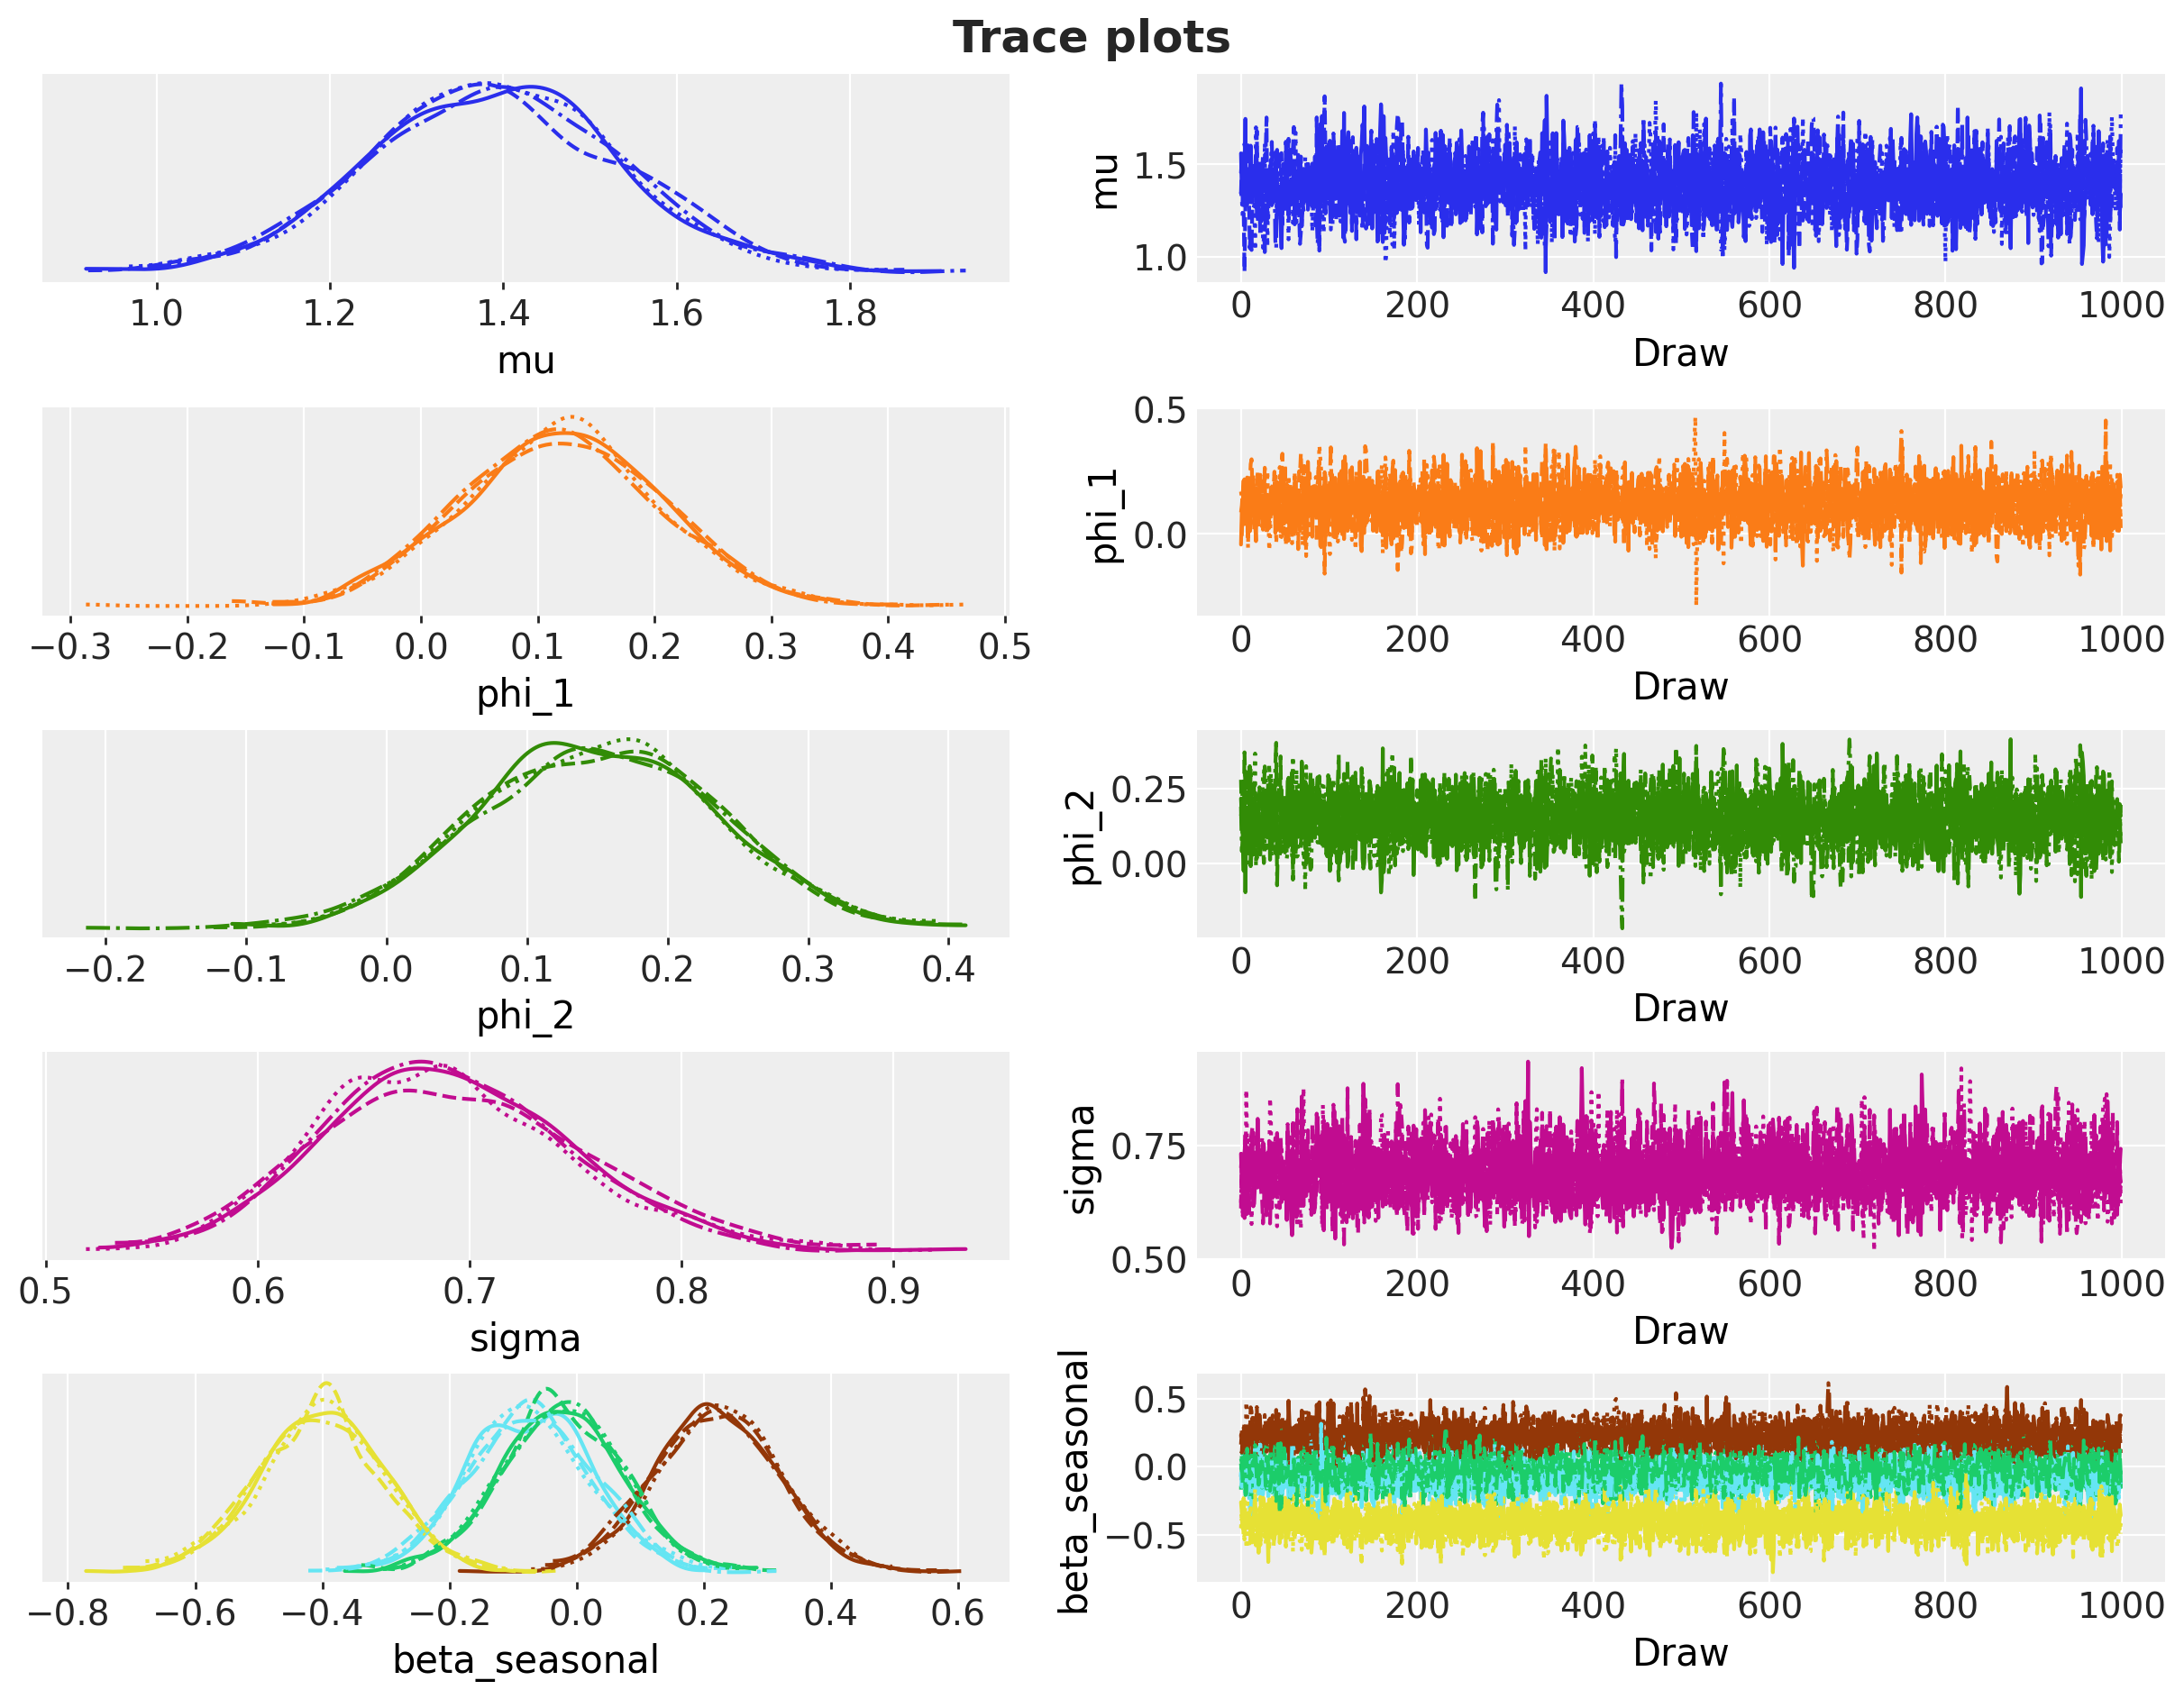

In [8]:
pc_trace = az.plot_trace_dist(
    tree,
    var_names=scalar_vars,
    compact=True,
    figure_kwargs={"figsize": (12, 9)},
)
pc_trace.viz["figure"].item().suptitle(
    "Trace plots",
    fontsize=18,
    fontweight="bold",
    y=1.03,
);

## In-sample fit

The tree's `posterior_predictive` group holds the one-step-ahead predictive of the `"obs"` site over the training window. Because `RightCensoredDistribution` samples from its *base* distribution, these draws describe latent demand-scale sales, so the interesting places are exactly where they disagree with the observed series: on capacity days the bands ride **above** the dashed cap that pins the black line down, which is the censored likelihood seeing through the cap. The first two steps run on placeholder lags and are dropped from the plot, and on the shaded stockout days the predictive is not conditioned on the recorded zeros (they are masked out of the likelihood), though the zeros do enter the AR carry as lagged values, exactly as in the blog post. This cell also defines the small plotting helpers (`stacked_draws` and `plot_band_forecast`) shared with the remaining band plots.

/Users/juanitorduz/Documents/numpyro_forecast/.venv/lib/python3.14/site-packages/arviz_plots/plots/lm_plot.py:360: UserWarning: When multiple credible intervals are plotted, it is recommended to map 'alpha' aesthetic to 'prob' dimension to differentiate between intervals.
  warnings.warn(


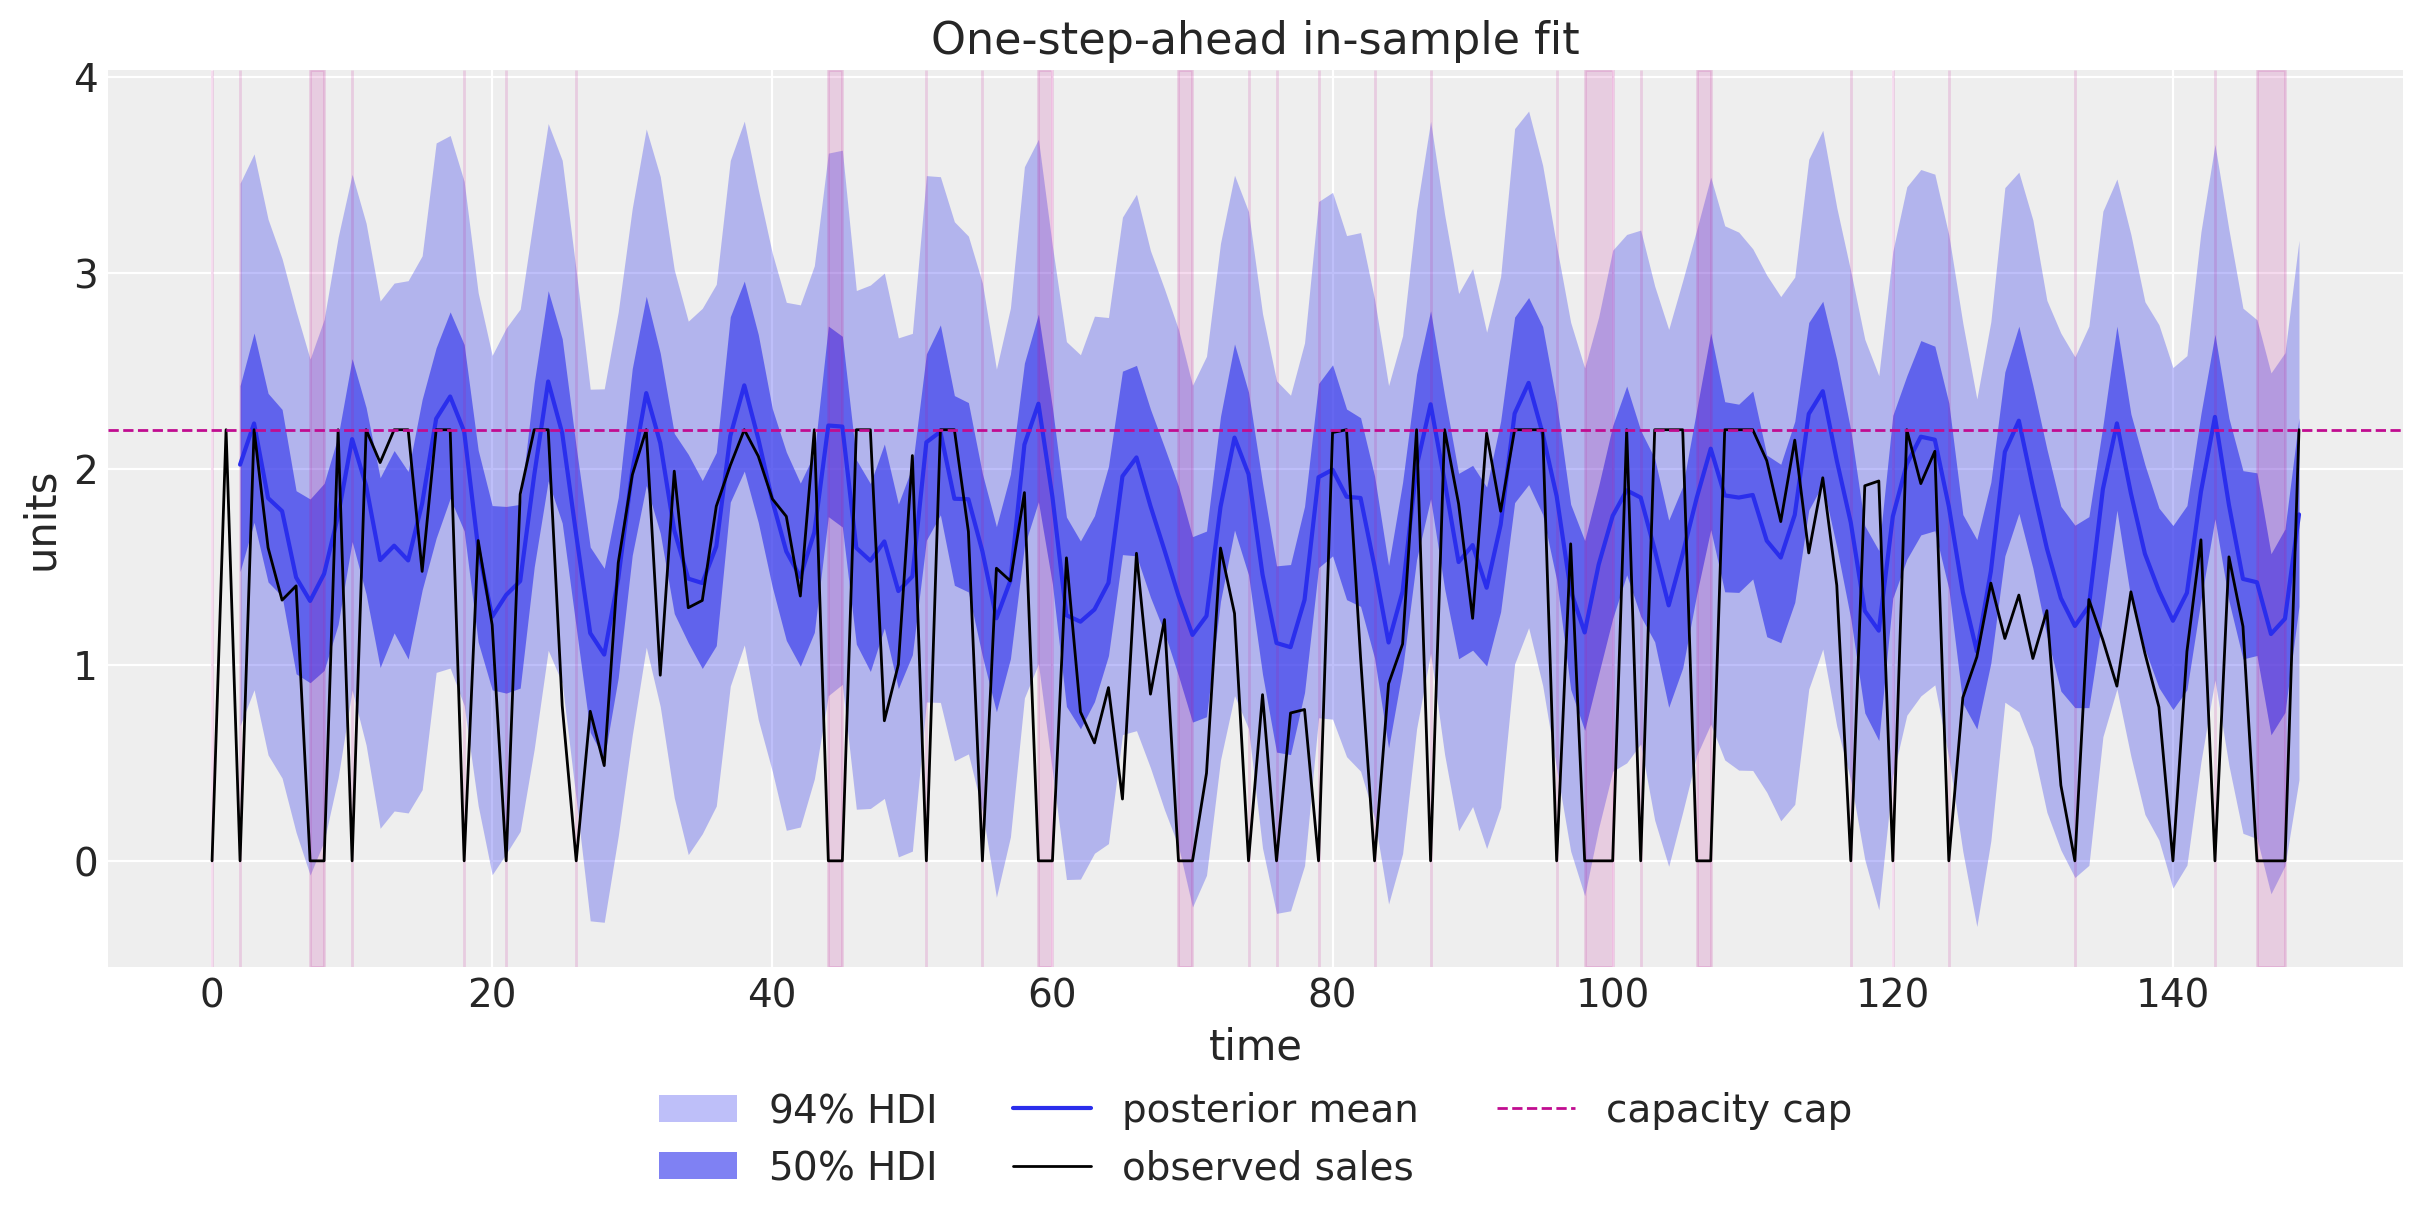

In [9]:
def hdi_label(prob: float, prefix: str = "") -> str:
    r"""Legend label for an HDI band, e.g. ``$94\%$ HDI``."""
    percent = f"{prob:.0%}".replace("%", r"\%")
    return f"{prefix}${percent}$ HDI"


hdi_probs = (0.5, 0.94)
hdi_alphas = [0.6, 0.3]  # 50% band darker, 94% band lighter


def stacked_draws(group: xr.DataTree | xr.DataArray, var: str) -> np.ndarray:
    """Stack a tree variable's ``(chain, draw)`` dims into a leading sample axis.

    Parameters
    ----------
    group
        A tree group holding ``var`` with dims ``(chain, draw, time, obs_dim)``
        (typed as the union ``tree[...]`` returns; a group always arrives here).
    var
        Name of the variable to extract.

    Returns
    -------
    np.ndarray
        The draws with shape ``(sample, time, obs_dim)``.
    """
    return (
        group.dataset[var]
        .stack(sample=("chain", "draw"))
        .transpose("sample", "time", "obs_dim")
        .to_numpy()
    )


def plot_band_forecast(
    draws: np.ndarray,
    x: np.ndarray,
    color: str,
    label_prefix: str = "",
    observed: Array | np.ndarray | None = None,
    figsize: tuple[float, float] = (12.0, 6.0),
) -> tuple[Axes, list[Artist]]:
    r"""Plot the posterior mean line and the $50\%$/$94\%$ HDI bands of ``draws``.

    Wraps ``predictions_to_datatree`` and ``az.plot_lm`` with the notebook-wide
    band styling (inner band darker via ``hdi_alphas``) and labels the artists.
    Overlays (observed series, split lines, extra reference lines) and the
    legend are the caller's responsibility.

    Parameters
    ----------
    draws
        Predictive draws with shape ``(sample, time, 1)``.
    x
        Numeric x values of length ``time``.
    color
        Matplotlib color for the bands and the mean line.
    label_prefix
        Prefix for the legend labels, e.g. ``"forecast "``.
    observed
        Optional observed data stored alongside the draws.
    figsize
        Figure size passed to ``plot_lm``.

    Returns
    -------
    tuple[Axes, list[Artist]]
        The axes and the labeled band and mean-line handles for the legend.
    """
    idata = predictions_to_datatree(draws, x, ["y"], observed=observed)
    pc = az.plot_lm(
        idata,
        y="obs",
        x="t",
        plot_dim="time",
        ci_kind="hdi",
        ci_prob=hdi_probs,
        smooth=False,
        point_estimate="mean",
        visuals={
            "ci_band": {"color": color},
            "observed_scatter": False,
            "pe_line": {"color": color, "alpha": 1.0, "width": 1.5},
        },
        aes={"alpha": ["prob"]},
        alpha=hdi_alphas,
        figure_kwargs={"figsize": figsize},
    )
    bands = pc.viz["ci_band"]["t"]
    band_94, band_50 = bands.sel(prob=0.94).item(), bands.sel(prob=0.5).item()
    band_94.set_label(hdi_label(0.94, prefix=label_prefix))
    band_50.set_label(hdi_label(0.5, prefix=label_prefix))
    pe_line = pc.viz["pe_line"]["t"].item()
    pe_line.set_label(f"{label_prefix}posterior mean")
    ax = pc.viz["figure"].item().axes[0]
    return ax, [band_94, band_50, pe_line]


train_pp = stacked_draws(tree["posterior_predictive"], "obs")[:, 2:, :]

ax, handles = plot_band_forecast(
    train_pp,
    time[2:n_train].astype(float),
    "C0",
    observed=train_data[2:],
)
ax.fill_between(
    time[:n_train],
    0,
    1,
    where=(np.asarray(is_available[:n_train]) == 0).tolist(),
    transform=ax.get_xaxis_transform(),
    color="C3",
    alpha=0.15,
    step="mid",
)
(obs_line,) = ax.plot(
    time[:n_train], np.asarray(sales_obs[:n_train]), color="black", lw=1, label="observed sales"
)
cap_line = ax.axhline(params.max_capacity, color="C3", ls="--", lw=1, label="capacity cap")
ax.legend(
    handles=[*handles, obs_line, cap_line],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=3,
)
ax.set(title="One-step-ahead in-sample fit", xlabel="time", ylabel="units");

## Forecasting demand

The `predictions` group already holds the out-of-sample draws of the `"forecast"` site under the full-availability, uncensored scenario encoded in the trailing covariate rows. We plot them against the **latent demand**, the series the model never saw, and score the forecast with the CRPS against that ground truth.

This is the money plot of the example: on its seasonal peaks the demand runs above the capacity cap, into territory where not a single observation exists, and the forecast mean follows it across the line. A model of *sales* cannot do this, because sales above the cap were never once recorded; the survival terms in the likelihood are what taught the model that capped days were floors, not values.

/Users/juanitorduz/Documents/numpyro_forecast/.venv/lib/python3.14/site-packages/arviz_plots/plots/lm_plot.py:360: UserWarning: When multiple credible intervals are plotted, it is recommended to map 'alpha' aesthetic to 'prob' dimension to differentiate between intervals.
  warnings.warn(


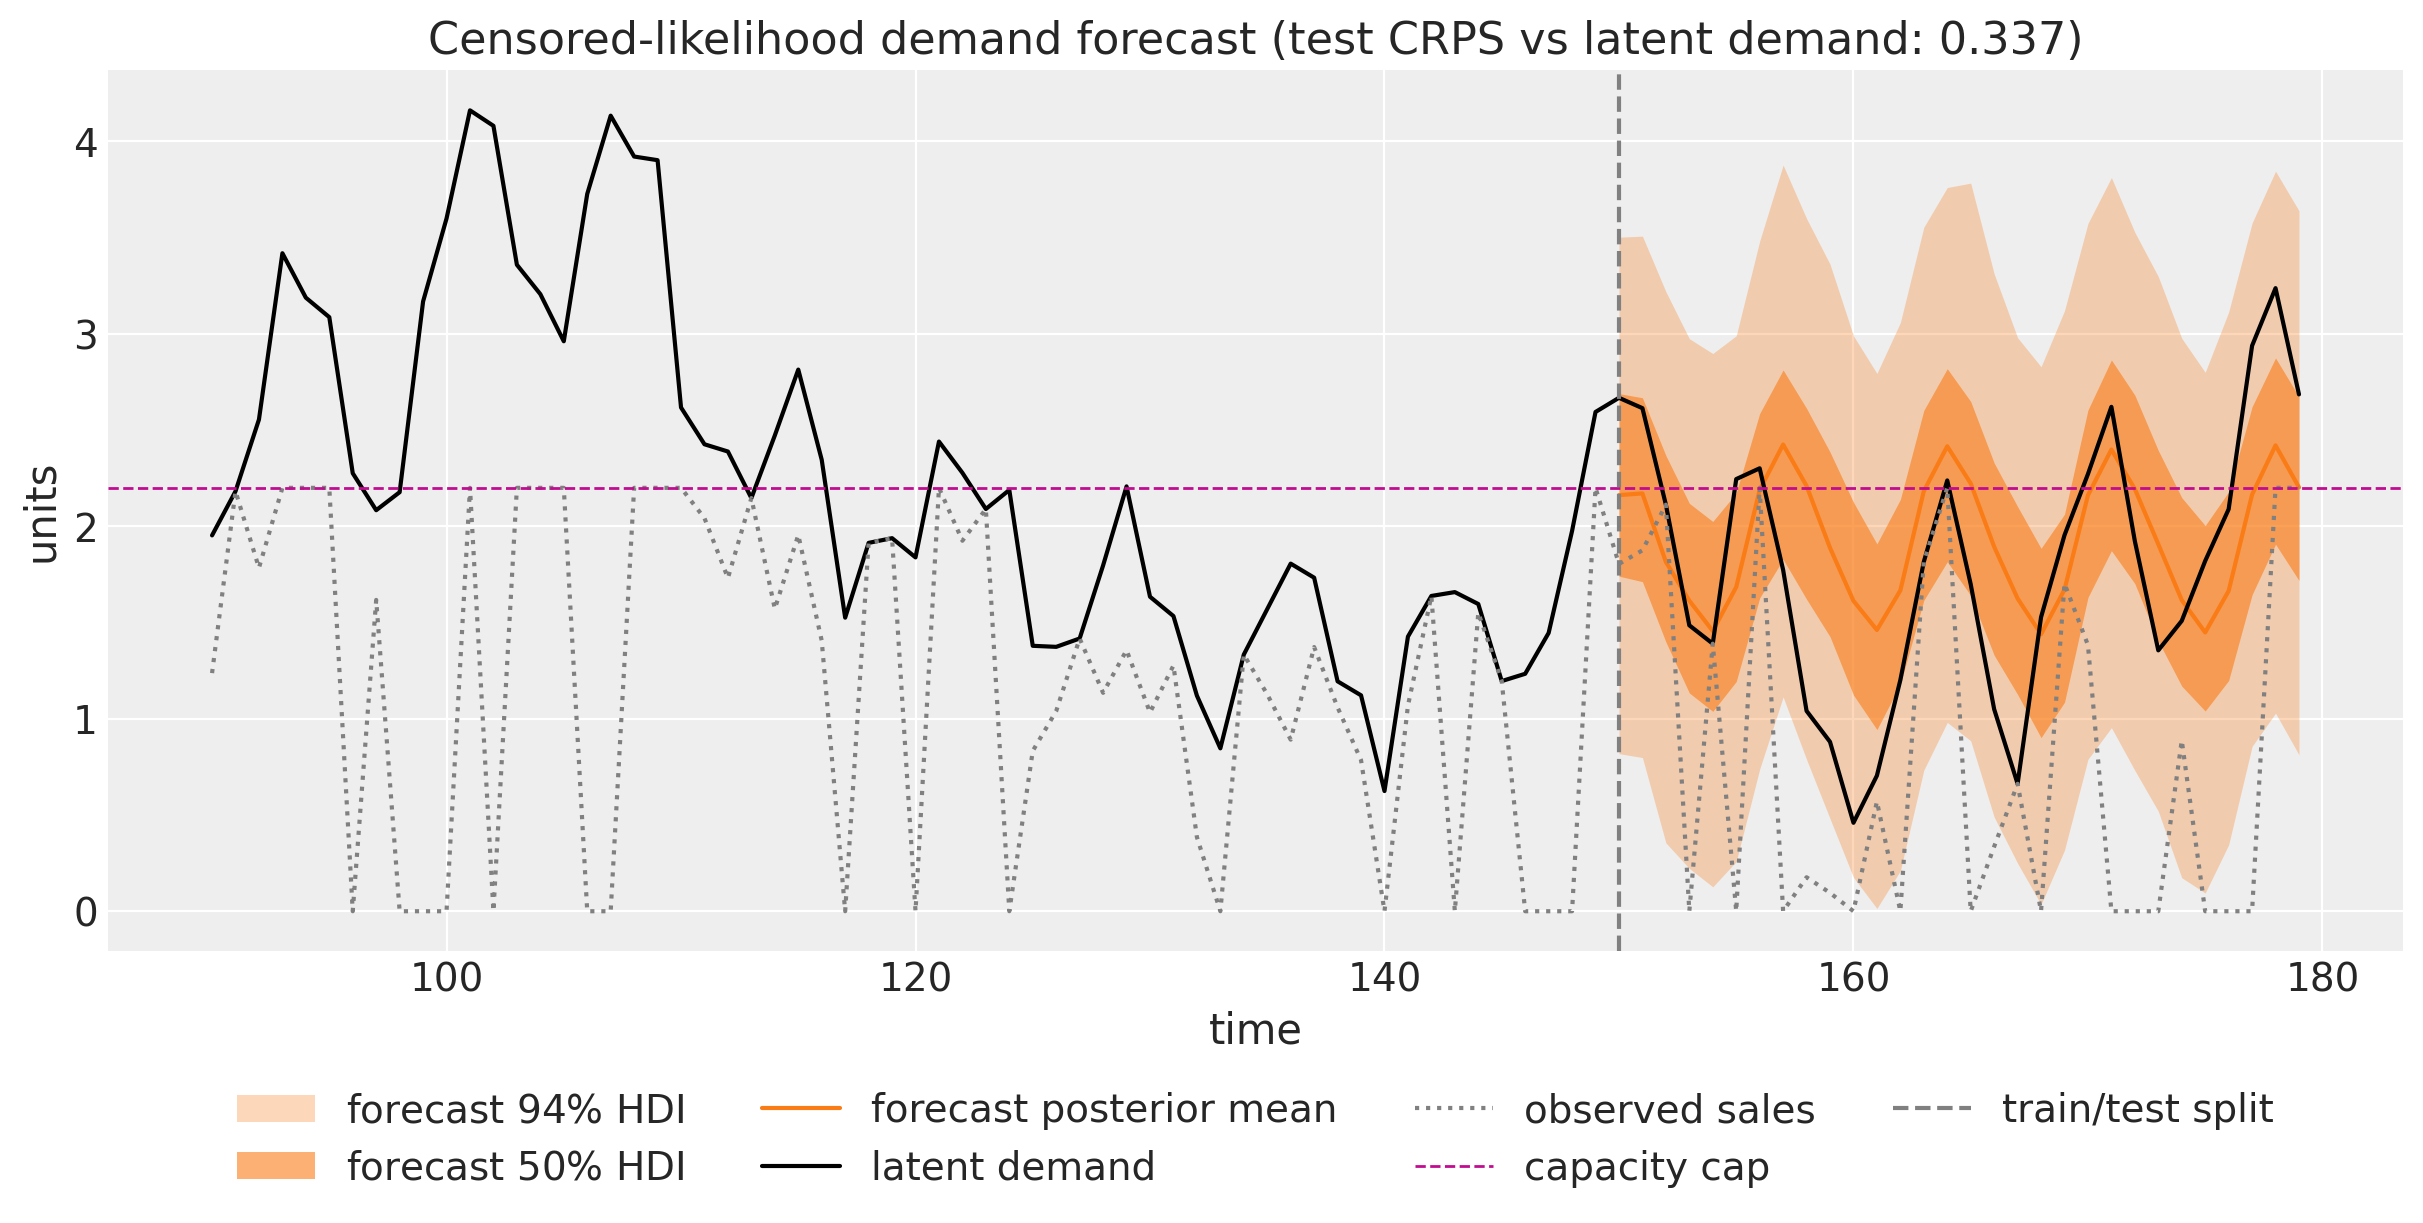

In [10]:
forecast_pp = stacked_draws(tree["predictions"], "obs")
crps_demand = eval_crps(forecast_pp, demand_test)

t_zoom = time[90:]
ax, handles = plot_band_forecast(forecast_pp, t_test.astype(float), "C1", label_prefix="forecast ")
(demand_line,) = ax.plot(
    t_zoom, np.asarray(demand[90:]), color="black", lw=1.5, label="latent demand"
)
(sales_line,) = ax.plot(
    t_zoom, np.asarray(sales_obs[90:]), ":", color="gray", lw=1.5, label="observed sales"
)
cap_line = ax.axhline(params.max_capacity, color="C3", ls="--", lw=1, label="capacity cap")
split_line = ax.axvline(n_train, color="gray", ls="--", label="train/test split")
ax.legend(
    handles=[*handles, demand_line, sales_line, cap_line, split_line],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=4,
)
ax.set(
    title=f"Censored-likelihood demand forecast (test CRPS vs latent demand: {crps_demand:.3f})",
    xlabel="time",
    ylabel="units",
);

## The naive comparison: ignoring the cap

How much of that is the censored likelihood, and how much just the AR(2) structure? With the censoring indicator at zero everywhere, `RightCensoredDistribution` *is* the plain $\text{Normal}$: every capped day is treated as an exact observation of $2.2$. So the naive baseline is the same model fit on a covariates tensor whose censoring column is zeroed, one line of code, and any difference between the two forecasts is attributable to the likelihood alone. Stockout days remain masked in both models; what changes is only how the capacity days enter.

In [11]:
covariates_naive = covariates.at[:, 2].set(0.0)

rng_key, rng_subkey = random.split(rng_key)
fit_naive = fit_mcmc(
    rng_subkey,
    model,
    train_data,
    covariates_naive[:n_train],
    num_warmup=1_000,
    num_samples=1_000,
    num_chains=4,
    kernel_kwargs={"target_accept_prob": 0.9},
)

rng_key, rng_subkey = random.split(rng_key)
tree_naive = to_datatree(
    rng_subkey,
    fit_naive,
    model,
    train_data,
    covariates_naive,
    posterior_dims={"pred_mean": ["time", "obs_dim"]},
)
az.summary(tree_naive, var_names=scalar_vars, ci_kind="hdi", ci_prob=0.94)

,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu,1.314,0.108,1.1,1.5,3080,2810,1.00,0.002,0.0013
phi_1,0.107,0.061,-0.0063,0.22,3679,2934,1.00,0.001,0.00075
phi_2,0.118,0.06,0.0058,0.23,4093,2661,1.00,0.00094,0.00068
sigma,0.524,0.0358,0.46,0.6,4266,2853,1.00,0.00055,0.00041
beta_seasonal[0],0.16,0.069,0.031,0.29,4687,3094,1.00,0.001,0.00073
beta_seasonal[1],-0.024,0.07,-0.16,0.11,5900,2857,1.00,0.00091,0.00067
beta_seasonal[2],-0.281,0.071,-0.42,-0.15,4605,2866,1.00,0.001,0.00075
beta_seasonal[3],-0.049,0.069,-0.18,0.081,5176,2823,1.00,0.00096,0.0007


Side by side, the two forecasts tell the whole story. The censored model tracks the latent demand above the cap; the naive model, trained to believe demand *was* $2.2$ on every capped day, pulls its level down toward the cap and undershoots the demand it is supposed to inform. This is the blog post's ARIMA conclusion reproduced from within a single model family.

/Users/juanitorduz/Documents/numpyro_forecast/.venv/lib/python3.14/site-packages/arviz_plots/plots/lm_plot.py:360: UserWarning: When multiple credible intervals are plotted, it is recommended to map 'alpha' aesthetic to 'prob' dimension to differentiate between intervals.
  warnings.warn(


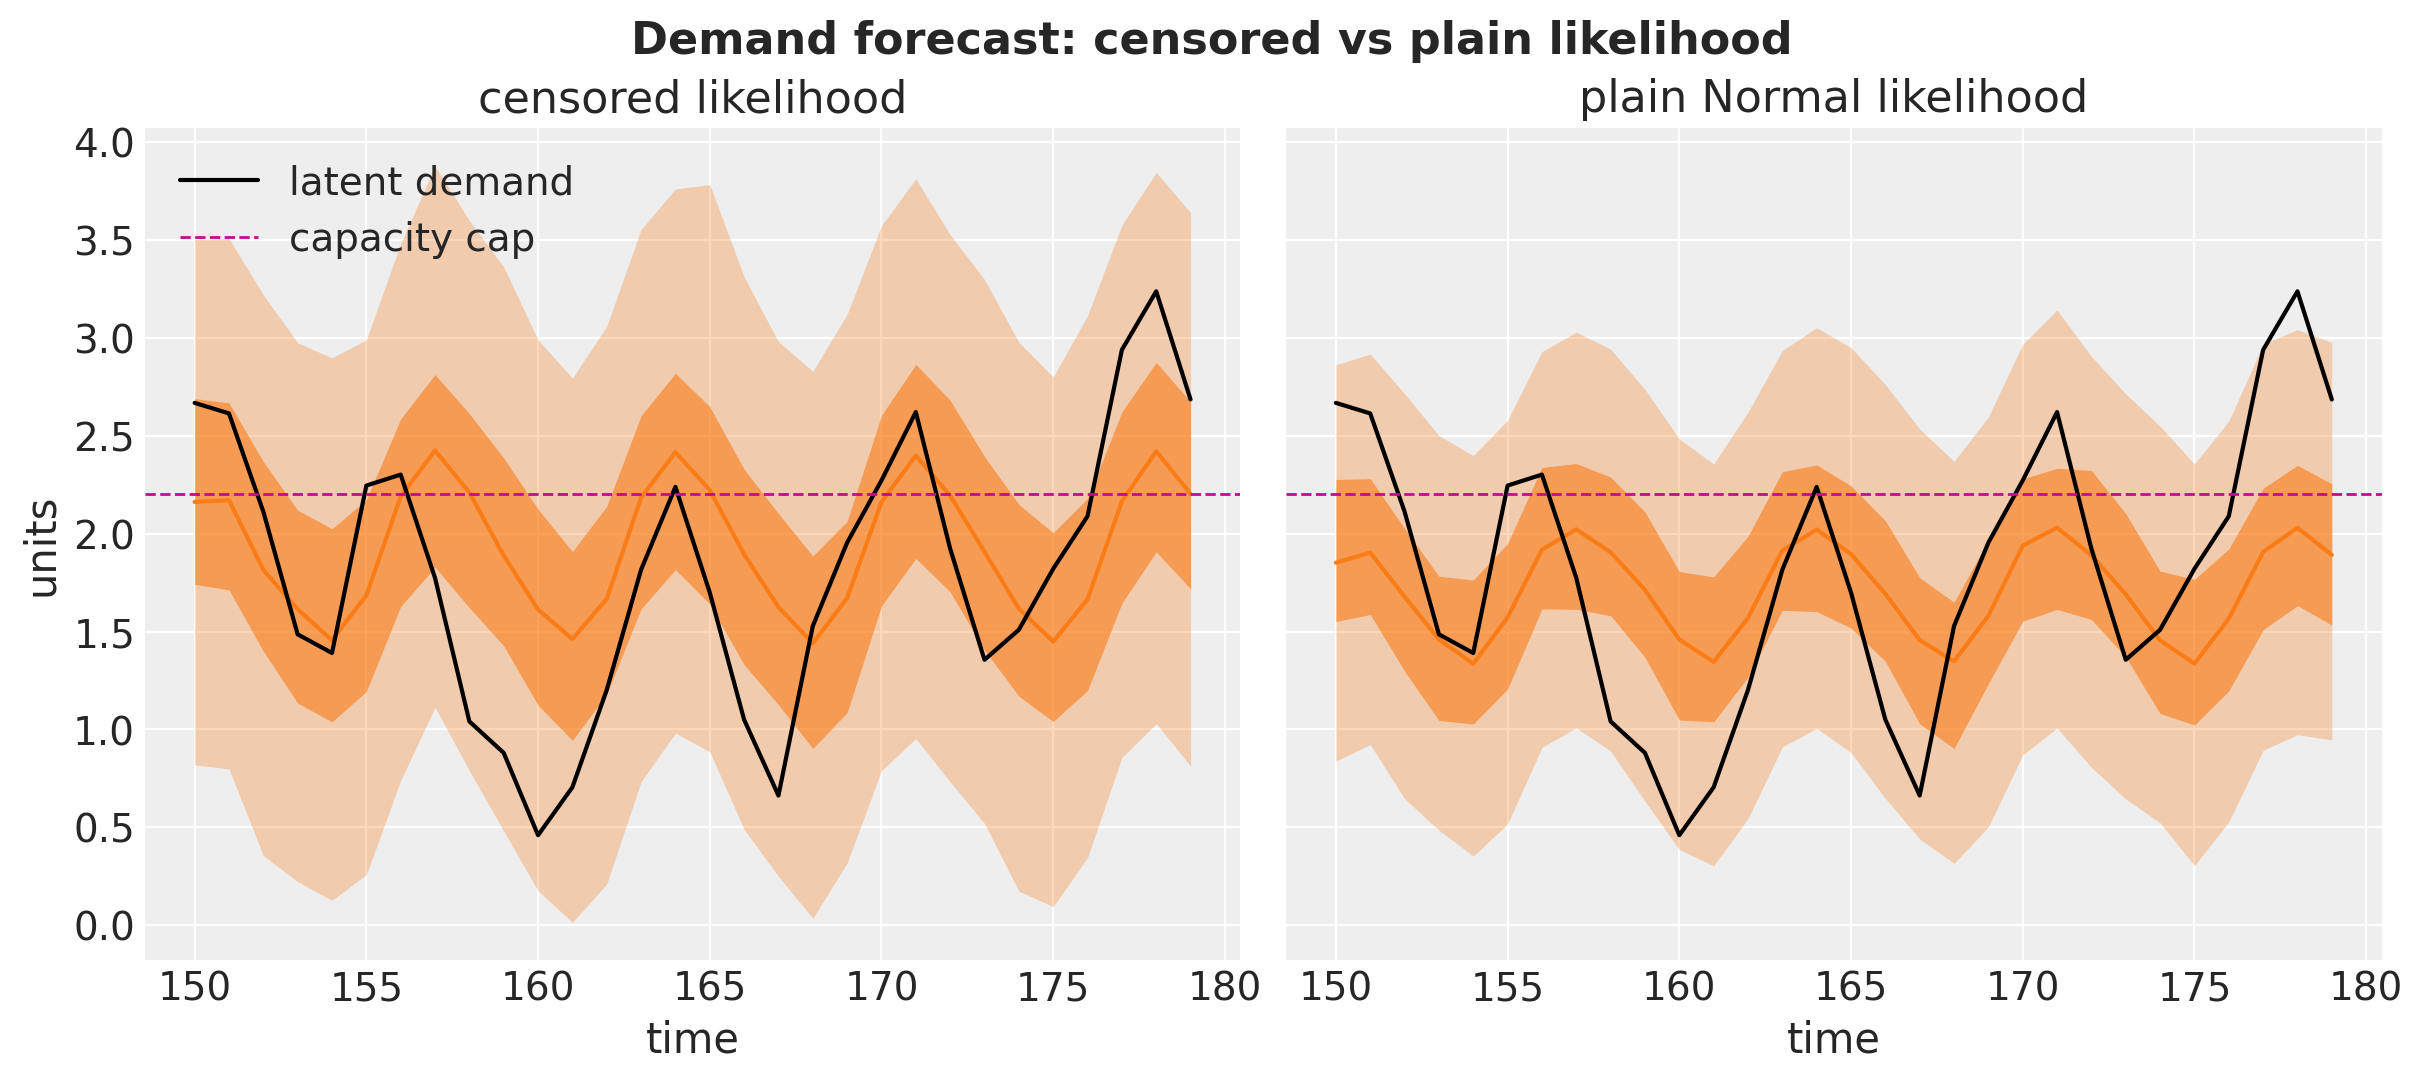

In [12]:
forecast_naive_pp = stacked_draws(tree_naive["predictions"], "obs")

series_names = ["censored likelihood", "plain Normal likelihood"]
both_draws = np.concatenate([forecast_pp, forecast_naive_pp], axis=-1)
idata_both = predictions_to_datatree(both_draws, t_test.astype(float), series_names)
pc = az.plot_lm(
    idata_both,
    y="obs",
    x="t",
    plot_dim="time",
    ci_kind="hdi",
    ci_prob=hdi_probs,
    smooth=False,
    point_estimate="mean",
    visuals={
        "ci_band": {"color": "C1"},
        "observed_scatter": False,
        "pe_line": {"color": "C1", "alpha": 1.0, "width": 1.5},
    },
    aes={"alpha": ["prob"]},
    alpha=hdi_alphas,
    figure_kwargs={"figsize": (12, 5), "sharex": True, "sharey": True},
)
axes = pc.viz["plot"]["t"]
for label in series_names:
    ax = axes.sel(series=label).item()
    ax.plot(t_test, np.asarray(demand[n_train:]), color="black", lw=1.5, label="latent demand")
    ax.axhline(params.max_capacity, color="C3", ls="--", lw=1, label="capacity cap")
    ax.set(title=label, xlabel="time", ylabel="")
axes.sel(series=series_names[0]).item().set(ylabel="units")
axes.sel(series=series_names[0]).item().legend(loc="upper left")
fig = pc.viz["figure"].item()
fig.suptitle(
    "Demand forecast: censored vs plain likelihood",
    fontsize=16,
    fontweight="bold",
    y=1.05,
);

## Evaluation

We score both models on the held-out $30$ days with [`evaluate_forecast`](https://juanitorduz.github.io/numpyro_forecast/reference/evaluate.evaluate_forecast.html), against two different notions of truth: the **latent demand** (the business quantity, known here because we simulated it) and the **observed sales** (the only truth available in production data, itself gated and capped over the test window). Alongside the point metrics and the CRPS we track the empirical coverage of the central $50\%$ and $94\%$ intervals.

In [13]:
metrics = {
    "mae": eval_mae,
    "rmse": eval_rmse,
    "crps": eval_crps,
    "coverage_50": partial(eval_coverage, alpha=0.5),
    "coverage_94": partial(eval_coverage, alpha=0.94),
}

rows = {
    ("censored likelihood", "latent demand"): evaluate_forecast(
        forecast_pp, demand_test, metrics=metrics
    ),
    ("plain Normal likelihood", "latent demand"): evaluate_forecast(
        forecast_naive_pp, demand_test, metrics=metrics
    ),
    ("censored likelihood", "observed sales"): evaluate_forecast(
        forecast_pp, sales_obs_test, metrics=metrics
    ),
    ("plain Normal likelihood", "observed sales"): evaluate_forecast(
        forecast_naive_pp, sales_obs_test, metrics=metrics
    ),
}
results_df = pd.DataFrame(rows).T.round(3)
results_df.index.names = ["model", "truth"]
results_df

,,mae,rmse,crps,coverage_50,coverage_94
model,truth,,,,,
censored likelihood,latent demand,0.485,0.584,0.337,0.533,1.000
plain Normal likelihood,latent demand,0.501,0.593,0.346,0.400,0.967
censored likelihood,observed sales,1.161,1.422,0.909,0.333,0.467
plain Normal likelihood,observed sales,1.030,1.250,0.826,0.300,0.467


Two readings, one per truth:

- **Against latent demand**, the censored model is better on every metric. The aggregate margins are modest, and they should be: on most test days demand sits below the cap, where the two likelihoods agree, so averaging over the whole window dilutes the difference. The calibration column is more telling than the point metrics: treating capped days as exact observations drags the naive model's mean down *and* shrinks its fitted noise scale (compare the $\sigma$ posteriors in the two summary tables), so its central $50\%$ interval covers noticeably less than nominal.
- **Against observed sales**, the ranking flips, and that is not a defect but the fresh retail example's lesson restated: the test window's observed sales are themselves gated and capped, so a *correct* demand forecast is penalized for sitting above the caps and the stockout zeros. Scoring against recorded sales systematically favors models that repeat the corruption. When the operational question is "how much should we stock?", the first reading is the one that matters, and in production, where latent demand is unavailable, this is an argument for evaluating on periods or stores with clean availability.

The aggregate table hides where the two models truly part ways, so we re-score on the days that drive capacity decisions: the test days whose latent demand exceeds the cap. These are exactly the days a planner would under-stock by trusting the naive model.

In [14]:
peak_days = np.asarray(demand_test[:, 0] > params.max_capacity)
print(f"test days with latent demand above the cap: {int(peak_days.sum())} of {forecast_horizon}")

peak_rows = {
    "censored likelihood": evaluate_forecast(
        forecast_pp[:, peak_days, :], demand_test[peak_days], metrics=metrics
    ),
    "plain Normal likelihood": evaluate_forecast(
        forecast_naive_pp[:, peak_days, :], demand_test[peak_days], metrics=metrics
    ),
}
peak_df = pd.DataFrame(peak_rows).T.round(3)
peak_df.index.name = "model"
peak_df

test days with latent demand above the cap: 10 of 30


,mae,rmse,crps,coverage_50,coverage_94
model,,,,,
censored likelihood,0.424,0.487,0.294,0.5,1.0
plain Normal likelihood,0.681,0.737,0.456,0.2,0.9


On the peak days the gap widens and the mechanism is plain: the naive model's forecast mean tops out below the cap it mistook for data (visible in the side-by-side plot above), so its errors against the demand it should inform are structural, not noise. The censored model's advantage is exactly where the money is: the days when there was more demand than shelf.

## Three ways to model censoring

The fresh retail stockout example closes its next-steps list with:

> Replace the mean-level factor with a censored likelihood: treat sales as latent demand right-censored by the available stock, which uses the same availability feature but models the mechanism instead of its average effect.

This notebook is that item made concrete, on a synthetic process where the recovered demand can be checked against ground truth. The three examples form a progression of mechanisms for the same business problem:

| Example | Censoring pattern | Mechanism | Demand forecast |
|---|---|---|---|
| [Availability TSB](https://juanitorduz.github.io/numpyro_forecast/examples/availability_tsb.html) | Binary: off-shelf days record zero | Freeze the probability-recursion updates where the product is off the shelf | Feed a full-availability scenario input |
| [Fresh retail stockouts](https://juanitorduz.github.io/numpyro_forecast/examples/fresh_retail_stockout.html) | Fractional: noisy within-day availability | Multiplicative availability factor on the mean, with a learned floor | Pin availability to one over the horizon |
| This notebook | Hard capacity cap plus stockout mask | Censored likelihood: density below the cap, survival mass at it | The generative recursion, unconstrained by the cap |

The choice between them is driven by what the data records and how the censoring operates:

- **Gating the recursion** (TSB) is the right tool when availability is binary and the model is a recursive smoother: off-shelf periods simply carry no information, so the estimate should freeze rather than decay.
- **A multiplicative factor** shines when availability is *fractional* and *noisy* (a reconstructed share of the day on the shelf): it models the average effect of partial availability on the mean, and its learned floor absorbs label noise such as recorded sales on supposedly out-of-stock days.
- **A censored likelihood** is the sharpest instrument when the censoring point is *known* per observation (a shelf capacity, an inventory level, a purchase limit): it models the mechanism itself rather than its average effect, at the price of trusting the recorded censoring indicator. All three share the same practical payoff: because availability and censoring are model *inputs*, the forecast becomes a scenario tool, and forecasting demand is just choosing the right trailing covariate rows.

In practice the mechanisms compose: a retailer with hourly stockout labels *and* known shelf capacities could use the fresh retail example's availability feature for partial days and this notebook's survival terms for capped ones.

## References

- Orduz, J. [*Demand Forecasting with Censored Likelihood*](https://juanitorduz.github.io/demand/). The blog post this notebook ports.
- NumPyro documentation: [Censored distributions](https://num.pyro.ai/en/stable/distributions.html#censored-distributions) (`RightCensoredDistribution` and friends, available from NumPyro `0.20.0`).
- Tobin, J. (1958). [*Estimation of Relationships for Limited Dependent Variables*](https://doi.org/10.2307/1907382). Econometrica, 26(1), 24-36. The classic censored-regression (Tobit) model.
- The [ARMA example](https://juanitorduz.github.io/numpyro_forecast/examples/arma.html) in this documentation, which introduces the two-scan pattern for AR-on-observations models.
- The [availability TSB example](https://juanitorduz.github.io/numpyro_forecast/examples/availability_tsb.html) and the [fresh retail stockout example](https://juanitorduz.github.io/numpyro_forecast/examples/fresh_retail_stockout.html) in this documentation: the sibling availability mechanisms compared above.